2026-06-14 14:43:55.875493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781448236.133887      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781448236.204310      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781448236.765771      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781448236.765824      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781448236.765827      57 computation_placer.cc:177] computation placer alr

Rows: 14400
Countries: 20
Removed noisy rows: 321
TRAIN: (8993, 30, 15)
VAL: (1928, 30, 15)
TEST: (1938, 30, 15)


2026-06-14 14:44:13.121647: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - loss: 0.1146 - mae: 0.3359 - val_loss: 0.0422 - val_mae: 0.1870 - learning_rate: 0.0010
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0394 - mae: 0.1726 - val_loss: 0.0292 - val_mae: 0.1340 - learning_rate: 0.0010
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0303 - mae: 0.1407 - val_loss: 0.0267 - val_mae: 0.1279 - learning_rate: 0.0010
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0277 - mae: 0.1337 - val_loss: 0.0246 - val_mae: 0.1226 - learning_rate: 0.0010
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0255 - mae: 0.1284 - val_loss: 0.0231 - val_mae: 0.1214 - learning_rate: 0.0010
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0239 - mae: 0.1264 - val_loss: 0.0220 - val_mae: 0.1210 - learning_rate: 0.0010
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 0.0222 - mae: 0.1238 - val_loss: 0.0208 - val_mae: 0.1204 - learnin

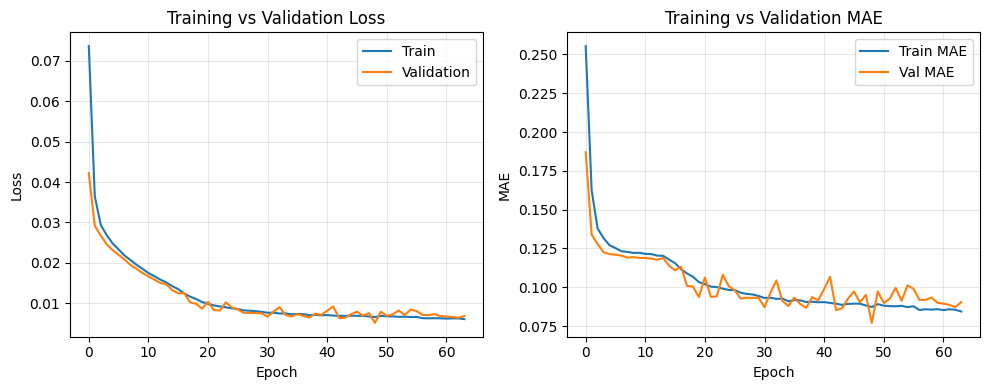

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step
Final Test Results
__________________________________________________
MAE : 42.2505
RMSE: 52.5447
MAPE: 10.0366 %
Accuracy: 89.96%
__________________________________________________

BASELINE (Naive Last Value)
MAE: 50.7483

Model vs Baseline:
  Model MAE:  42.2505
  Baseline MAE: 50.7483
  Model is 16.7% BETTER than baseline

Test Results

Country         Pred       Actual     MAE        RMSE      
------------------------------------------------------------
Australia           426.81     402.35      24.46      24.46
Australia       Accuracy: 93.92%
Brazil              496.89     477.27      19.62      19.62
Brazil          Accuracy: 95.89%
Canada              526.55     517.96       8.59       8.59
Canada          Accuracy: 98.34%
China               472.57     429.81      42.76      42.76
China           Accuracy: 90.05%
France              496.03     479.80      16.24      16.24
France          Accuracy: 96.62%
Germany             353.98     3

In [1]:
#Final CO2 Forecaster

import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt #draw graphs
from sklearn.preprocessing import MinMaxScaler,LabelEncoder #converts values into 0,1 and country names into numeric id
from sklearn.metrics import mean_absolute_error,mean_squared_error
import tensorflow as tf #deep learning library
from tensorflow.keras.layers import LSTM,Dense,Dropout,Input,Embedding,Flatten,Concatenate,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

#safe random numbers evey run, model initialization, results
SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
#loads csv into dataframe
df=pd.read_csv("/kaggle/input/climate-and-energy-consumption-dataset-20202024/global_climate_energy_2020_2024.csv")

df['date']=pd.to_datetime(df['date'],dayfirst=True,errors='coerce')#convert dates
df=df.dropna(subset=['date']) #remove row if date failed
#clean country names
df['country']=df['country'].astype(str).str.strip().str.title()
df=df.sort_values(['country','date']).reset_index(drop=True)#sort dates

print("Rows:",len(df))
print("Countries:",df['country'].nunique())

# remove extreme co2 noise
df['co2_mean_raw']=df.groupby('country')['co2_emission'].transform('mean')
df['co2_std_raw']=df.groupby('country')['co2_emission'].transform('std')
df['co2_zscore']=(df['co2_emission']-df['co2_mean_raw'])/(df['co2_std_raw']+1e-6)#how much unusual value is
before=len(df)
df=df[df['co2_zscore'].abs()<2] #remove extreme values
print("Removed noisy rows:",before-len(df))

# smooth daily fluctuations, reducess noise
df['co2_smooth']=df.groupby('country')['co2_emission'].transform(lambda x:x.rolling(window=7,min_periods=1).mean())

CO2_COLUMN="co2_smooth"

#extract calendar features
df['month']=df['date'].dt.month
df['day_of_year']=df['date'].dt.dayofyear
df['day_of_week']=df['date'].dt.dayofweek
#time is circle
df['month_sin']=np.sin(2*np.pi*df['month']/12)
df['month_cos']=np.cos(2*np.pi*df['month']/12)

df['doy_sin']=np.sin(2*np.pi*df['day_of_year']/365)
df['doy_cos']=np.cos(2*np.pi*df['day_of_year']/365)

df['dow_sin']=np.sin(2*np.pi*df['day_of_week']/7)
df['dow_cos']=np.cos(2*np.pi*df['day_of_week']/7)

#creates past co2 values
for lag in [1,7,14,30]:
    df[f'lag_{lag}']=df.groupby('country')[CO2_COLUMN].shift(lag)

# target
df['co2_next_day']=df.groupby('country')[CO2_COLUMN].shift(-1)
df['target']=df['co2_next_day']

FEATURES=['co2_smooth','industrial_activity_index','energy_consumption','avg_temperature','energy_price','lag_1','lag_7','lag_14','lag_30','month_sin','month_cos','doy_sin','doy_cos','dow_sin','dow_cos']

df=df.dropna(subset=FEATURES+['target'])
df=df.reset_index(drop=True)

# country encoding
country_encoder=LabelEncoder()#country index for embedding layer
df['country_id']=country_encoder.fit_transform(df['country'])
NUM_COUNTRIES=len(country_encoder.classes_)
WINDOW=30

# store sequences(30days)
def time_split_per_country(df,window):
    X_train,X_val,X_test=[],[],[]#store sequences(30days)
    C_train,C_val,C_test=[],[],[]#country id
    y_train,y_val,y_test=[],[],[]#target co2

    for c in sorted(df['country'].unique()):
        df_c=df[df['country']==c].reset_index(drop=True)#one country data

        if len(df_c)<window+20:#skip small countries with dataset 
            continue

        x=df_c[FEATURES].values#input features
        y=df_c['target'].values#target
        cid=df_c['country_id'].iloc[0]#country id

        n=len(x)-window #number of sequences
        t1,t2=int(n*0.7),int(n*0.85) #split training validation test

        for i in range(n):#loop sliding window
            xi=x[i:i+window]#input past 30days
            yi=y[i+window]#next day

            if i<t1:
                X_train.append(xi);C_train.append(cid);y_train.append(yi)
            elif i<t2:
                X_val.append(xi);C_val.append(cid);y_val.append(yi)
            else:
                X_test.append(xi);C_test.append(cid);y_test.append(yi)

    return(
        np.array(X_train,dtype=np.float32),np.array(C_train,dtype=np.int32),np.array(y_train,dtype=np.float32).reshape(-1,1),#convert into array
        np.array(X_val,dtype=np.float32),np.array(C_val,dtype=np.int32),np.array(y_val,dtype=np.float32).reshape(-1,1),
        np.array(X_test,dtype=np.float32),np.array(C_test,dtype=np.int32),np.array(y_test,dtype=np.float32).reshape(-1,1)
    )
#create dataset
X_train_raw,C_train,y_train_raw,\
X_val_raw,C_val,y_val_raw,\
X_test_raw,C_test,y_test_raw=time_split_per_country(df,WINDOW)

print("TRAIN:",X_train_raw.shape)
print("VAL:",X_val_raw.shape)
print("TEST:",X_test_raw.shape)

#[0,1]range
scaler_x=MinMaxScaler()
scaler_y=MinMaxScaler()

scaler_x.fit(X_train_raw.reshape(-1,len(FEATURES)))
scaler_y.fit(y_train_raw)#learns target scaling, fit only on training data

#flatten time seq, scale, reshape back
def scale_X(X):
    s,w,f=X.shape
    return scaler_x.transform(X.reshape(-1,f)).reshape(s,w,f).astype(np.float32)

#apply scaling
X_train=scale_X(X_train_raw)
X_val=scale_X(X_val_raw)
X_test=scale_X(X_test_raw)

y_train=scaler_y.transform(y_train_raw).astype(np.float32)
y_val=scaler_y.transform(y_val_raw).astype(np.float32)
y_test=scaler_y.transform(y_test_raw).astype(np.float32)

# model
def build_model(num_countries):
    feature_input=Input(shape=(WINDOW,len(FEATURES)))

    x=LSTM(64,return_sequences=True,dropout=0.2,recurrent_dropout=0.2,kernel_regularizer=l2(1e-4))(feature_input)
    x=BatchNormalization()(x)#normalize activations,training stable, speed up convergence
    x=Dropout(0.2)(x)#randomly drops 20% of neurons, prevents overffinting

    x=LSTM(32,dropout=0.2,recurrent_dropout=0.2,kernel_regularizer=l2(1e-4))(x)#second lstm layer,learns higher level paterns
    x=BatchNormalization()(x)
    x=Dropout(0.3)(x)

    country_input=Input(shape=(1,),dtype=tf.int32)
    emb=Embedding(num_countries,8)(country_input)#countryid = dense vector of size 8, similarity between countries
    emb=Flatten()(emb)#for concatenation

    x=Concatenate()([x,emb])#lstm output+ country embeddig

    x=Dense(32,activation="relu",kernel_regularizer=l2(1e-4))(x)
    x=Dropout(0.2)(x)
    x=Dense(16,activation="relu",kernel_regularizer=l2(1e-4))(x)
    out=Dense(1)(x)#output layer

    model=tf.keras.Model([feature_input,country_input],out)#input,output

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001,clipnorm=1.0),#controls learning speed
        loss='huber',#mix mae mse
        metrics=['mae']
    )
    return model

model=build_model(NUM_COUNTRIES)

early_stop=EarlyStopping(monitor="val_loss",patience=15,restore_best_weights=True,verbose=1)#stop training if validation loss doesnt improve for 15 epoches
lr_reduce=ReduceLROnPlateau(monitor="val_loss",patience=7,factor=0.5,min_lr=1e-6,verbose=1)#if model stops improving reduce learning rate until 1e-6

history=model.fit( #train model
    [X_train,C_train],y_train,
    validation_data=([X_val,C_val],y_val),
    epochs=100,
    batch_size=32,#32 samples at once
    callbacks=[early_stop,lr_reduce],
    verbose=1
)

# training curves, plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True,alpha=0.3)
plt.subplot(1,2,2)
plt.plot(history.history["mae"],label="Train MAE")
plt.plot(history.history["val_mae"],label="Val MAE")
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

#test metrics
pred=model.predict([X_test,C_test],batch_size=256,verbose=1)
pred=scaler_y.inverse_transform(pred)
true=scaler_y.inverse_transform(y_test)

mae=mean_absolute_error(true,pred)
rmse=np.sqrt(mean_squared_error(true,pred))
mape=np.mean(np.abs((true-pred)/(true+1e-6)))*100 #percentage error

print("Final Test Results")
print("_"*50)
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"Accuracy: {100-mape:.2f}%")
print("_"*50)

#Naive baseline
naive_pred=X_test_raw[:,-1,0]
naive_mae=mean_absolute_error(true.flatten(),naive_pred) #compare naive vs lstm
print(f"\nBASELINE (Naive Last Value)")
print(f"MAE: {naive_mae:.4f}")
print(f"\nModel vs Baseline:")
print(f"  Model MAE:  {mae:.4f}")
print(f"  Baseline MAE: {naive_mae:.4f}")
if mae<naive_mae:
    improvement=((naive_mae-mae)/naive_mae)*100
    print(f"  Model is {improvement:.1f}% BETTER than baseline")
else:
    degradation=((mae-naive_mae)/naive_mae)*100
    print(f"  Model is {degradation:.1f}% WORSE than baseline")

# country level evaluation
def inverse(y): #model predicts scaled values values(0-1)
    return scaler_y.inverse_transform(y)

print("\nTest Results\n")

results=[]

def safe_forward(x, c):
    return model([x, c], training=False)


for c in sorted(df['country'].unique()):  # evaluates model per country
    df_c = df[df['country'] == c].reset_index(drop=True)

    if len(df_c) < WINDOW + 20:
        continue

    cid = country_encoder.transform([c])[0]  # country id

    # final prediction step for one country
    x = df_c.iloc[-WINDOW:][FEATURES].values.astype(np.float32)
    x = scaler_x.transform(x)
    x = x.reshape(1, WINDOW, len(FEATURES)).astype(np.float32)

    actual = float(df_c["target"].iloc[-1])

    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    c_tf = tf.convert_to_tensor([cid], dtype=tf.int32)

    pred = safe_forward(x_tf, c_tf).numpy()
    pred = inverse(pred)[0, 0]  # reverse scaling

    mae = abs(pred - actual)
    rmse = np.sqrt((pred - actual) ** 2)

    results.append((c, pred, actual, mae, rmse))


print(f"{'Country':15} {'Pred':10} {'Actual':10} {'MAE':10} {'RMSE':10}")
print("-" * 60)

mae_list = []
rmse_list = []
acc_list = []

for r in results:
    c, p, a, mae, rmse = r
    mae_list.append(mae)
    rmse_list.append(rmse)

    print(f"{c:15} {p:10.2f} {a:10.2f} {mae:10.2f} {rmse:10.2f}")

    acc = max(0, (1 - mae / a) * 100)
    acc_list.append(acc)

    print(f"{c:15} Accuracy: {acc:.2f}%")

print("\nOVERALL METRICS")
print("MAE:",np.mean(mae_list))
print("RMSE:",np.mean(rmse_list))
print("nRMSE:",np.mean(rmse_list)/np.mean([r[2] for r in results]))
print("Accuracy:",np.mean(acc_list)," %")